# Hijack Sandals — DealPOS API EDA
**Reports:** Sales by Product/Channel | Best Seller Ranking | Inventory per Outlet | Outlet Performance

## 0. Setup & Authentication

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

BASE_URL   = 'https://hijacksandals.dealpos.net/api/v3'
CLIENT_ID  = '019c9a25-05c4-7a38-b04a-dd1efe4c08ef'
CLIENT_SECRET = '019c9a26-51bf-7232-ae0a-4c702ba345e9'

In [2]:
def get_token():
    resp = requests.post(
        f'{BASE_URL}/Token/OAuth2',
        json={'client_id': CLIENT_ID, 'client_secret': CLIENT_SECRET},
        headers={'Content-Type': 'application/json'}
    )
    resp.raise_for_status()
    data = resp.json()
    
    # token_type = "Bearer", token = just the access_token value
    token = f"{data['token_type']} {data['access_token']}"
    print(f'✅ Token acquired: {token[:30]}...')
    return token

TOKEN = get_token()
HEADERS = {
    'Authorization': TOKEN,
    'Content-Type': 'application/json',
    'Accept': '*/*',
    'User-Agent': 'python-requests/2.28.0'
}

✅ Token acquired: Bearer eyJhbGciOiJIUzI1NiIsInR...


In [3]:
def api_get(endpoint, params=None):
    """Generic GET — no Content-Type on GET requests"""
    url = f'{BASE_URL}/{endpoint}'
    resp = requests.get(url, headers={
        'Authorization': TOKEN,
        'Accept': '*/*'
    }, params=params)
    
    if not resp.ok:
        print(f'Status: {resp.status_code}')
        print(f'URL: {resp.url}')
        print(f'Response: {resp.text}')
        resp.raise_for_status()
    
    return resp.json()

# Keep Content-Type only for POST/PUT
def api_post(endpoint, body):
    url = f'{BASE_URL}/{endpoint}'
    resp = requests.post(url, headers={
        'Authorization': TOKEN,
        'Accept': '*/*',
        'Content-Type': 'application/json'
    }, json=body)
    resp.raise_for_status()
    return resp.json()

## 1. Outlets — Master Data

In [4]:
# GET /Outlet — list all outlets
outlets_raw = api_get('Outlet', params={'Suspended': 'false'})
df_outlets = pd.DataFrame(outlets_raw)
print(f'Total outlets: {len(df_outlets)}')
df_outlets.head(20)

Total outlets: 62


,ID,Name,Code,Suspended
0,a95cee58-534e-47ef-9427-043337e5ebf0,Marketplace,MKP,False
1,b41d6d9b-bc55-4db1-8043-095e135e9116,Transit Cikutra,TC,False
2,9f1ba3bd-213c-4fb1-b3ba-0bb4afa4bbf8,Akira Zozo Town,AZT,False
3,757cc7f3-0583-4188-b48a-0fdafd3f7507,Reject A,Reject A,False
4,019bdaac-c6d6-7bfd-b602-120dadd4fe71,Tunjungan Plaza Mall,TPM,False
5,0e782bdf-6663-44fe-a1f5-12a7bff0ae2a,Marketing - (kol or Fnf),MKI,False
6,15c6c6e0-532a-4caa-8cd6-1ac64a5b26d6,Transit Toko Jakarta,TTJ,False
7,437a4637-c549-4e1f-9ec6-1b5c97fbfe2d,Fishy Business Offline,FBOF,False
8,d3a9b25d-629c-4a05-959a-1e0d94711947,Global Website,Global,False
9,58a4cc02-fa59-45ff-91a5-20801d616a54,Transit Toko Bandung,TTB,False


In [5]:
# GET /Outlet/Detail — get outlet details with tags/channels
outlets_detail_raw = api_get('Outlet/Detail', params={'Code': 'TTB','Name':'Transit Toko Bandung'})
df_outlets_detail = pd.DataFrame(outlets_detail_raw)
print(f'Outlet detail columns: {df_outlets_detail.columns.tolist()}')
# df_outlets_detail.to_csv('outlet_master_detail2.csv')
df_outlets_detail

Outlet detail columns: ['ID', 'Code', 'Name', 'Email', 'SalesTarget', 'Suspended', 'MinimumInventory', 'maximumInventory', 'OrderDisplayBroadcastMode', 'ReceiptTemplate']


,ID,Code,Name,Email,SalesTarget,Suspended,MinimumInventory,maximumInventory,OrderDisplayBroadcastMode,ReceiptTemplate
Code,58a4cc02-fa59-45ff-91a5-20801d616a54,TTB,Transit Toko Bandung,,0,False,0,0,0,B1
OutletName,58a4cc02-fa59-45ff-91a5-20801d616a54,TTB,Transit Toko Bandung,,0,False,0,0,0,HIJACK SANDALS
Field,58a4cc02-fa59-45ff-91a5-20801d616a54,TTB,Transit Toko Bandung,,0,False,0,0,0,None
Address,58a4cc02-fa59-45ff-91a5-20801d616a54,TTB,Transit Toko Bandung,,0,False,0,0,0,"Jl. Dahlia No.1A, Merdeka, Kec. Sumur Bandung,..."
ContactInfo,58a4cc02-fa59-45ff-91a5-20801d616a54,TTB,Transit Toko Bandung,,0,False,0,0,0,Phone/WA : +62811 218 7711\nIG : @hijacksandal...


## 2. Sales by Product & Channel

In [6]:
# GET /Report/WithItemNetSalesComplete — most detailed sales breakdown
# Includes: outlet, product, variant, net sales per item
sales_raw = api_get('Report/WithItemNetSalesComplete', params={
    'StartDate': DATE_START,
    'EndDate': DATE_END
})
df_sales = pd.DataFrame(sales_raw)
print(f'Shape: {df_sales.shape}')
print(f'Columns: {df_sales.columns.tolist()}')
df_sales['Data'][0]

NameError: name 'DATE_START' is not defined

# REPORT PER OUTLET AGGREGATED
## SUM INVOICE PER TAG IN EACH OUTLET NEED TO KNOW

In [72]:
# GET /Report/InvoiceGroupByOutletNTag — sales grouped by outlet + channel/tag
json_body={"From": "2025-01-01","To": "2026-12-31","Outlet": ["Marketplace","Transit Cikutra"],
    "Tag": [
      "Shopee",
      "Tokopedia",
      "TikTok"
    ]
}

sales_by_tag_raw = api_post('Report/InvoiceGroupByOutletNTag',body=json_body)
df_sales_by_tag = pd.DataFrame(sales_by_tag_raw)
print(f'Shape: {df_sales_by_tag.shape}')
print(f'Columns: {df_sales_by_tag.columns.tolist()}')
df_sales_by_tag.head(10)

Shape: (1029, 5)
Columns: ['Outlet', 'Tag', 'Sum', 'Count', 'Date']


,Outlet,Tag,Sum,Count,Date
0,Marketplace,TikTok,88660173,183,2026-03-16T00:00:00
1,Marketplace,Normal,0,1,2026-03-16T00:00:00
2,Marketplace,Shopee,342416100,711,2026-03-16T00:00:00
3,Marketplace,Normal,160363,9,2026-03-14T00:00:00
4,Marketplace,Shopee,159625400,338,2026-03-14T00:00:00
5,Marketplace,TikTok,41571119,84,2026-03-14T00:00:00
6,Marketplace,TikTok,39165440,85,2026-03-13T00:00:00
7,Marketplace,Shopee,223832700,470,2026-03-13T00:00:00
8,Marketplace,Normal,200540,13,2026-03-13T00:00:00
9,Marketplace,Normal,169756,12,2026-03-12T00:00:00


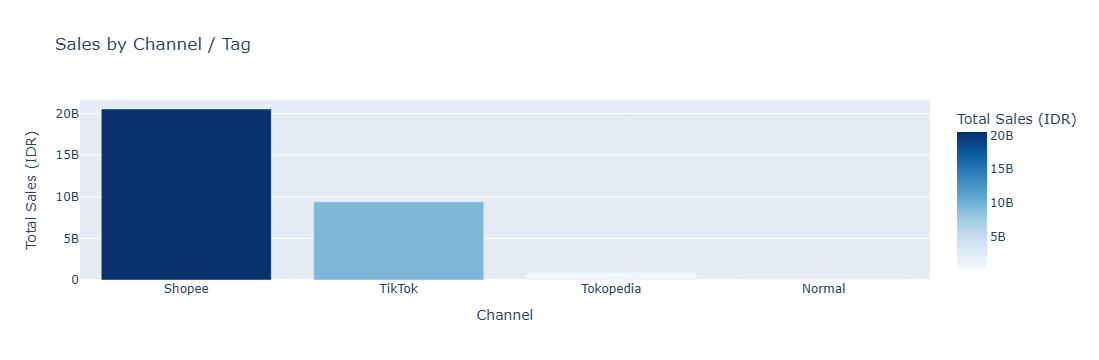

In [75]:
# ── Sales by Channel (Tag) ──────────────────────────────────────
# Adjust column names below after inspecting df_sales_by_tag.columns above
# Common column names in DealPOS: OutletName, Tag, TotalSales, TotalQty

# Example — update 'Tag' and 'TotalSales' to match actual column names
channel_col = 'Tag'          # update if different
sales_col   = 'Sum'   # update if different

if channel_col in df_sales_by_tag.columns:
    df_by_channel = df_sales_by_tag.groupby(channel_col)[sales_col].sum().reset_index()
    df_by_channel = df_by_channel.sort_values(sales_col, ascending=False)

    fig = px.bar(df_by_channel, x=channel_col, y=sales_col,
                 title='Sales by Channel / Tag',
                 labels={sales_col: 'Total Sales (IDR)', channel_col: 'Channel'},
                 color=sales_col, color_continuous_scale='Blues')
    fig.show()
else:
    print(f'Column "{channel_col}" not found. Available: {df_sales_by_tag.columns.tolist()}')
    print('Update channel_col variable above to match.')

## 3. Best Seller / Best Product Ranking

In [12]:
# GET /Report/ProductSold — product sold qty and revenue
DATE_START='2026-03-01T00:00:00'
DATE_END='2026-03-17T00:00:00'
product_sold_raw = api_get('Report/ProductSold', params={
    'StartDate': DATE_START,
    'EndDate': DATE_END
})
df_product_sold = pd.DataFrame(product_sold_raw)
print(f'Shape: {df_product_sold.shape}')
print(f'Columns: {df_product_sold.columns.tolist()}')
df_product_sold.head(10)

Shape: (100, 6)
Columns: ['Name', 'Code', 'Quantity', 'Cost', 'Sales', 'Profit']


,Name,Code,Quantity,Cost,Sales,Profit
0,SICEPAT REG,None,90871,"5,800","423,131,298","423,125,498"
1,Piece Goodie Bag Blach,FTBR-BL,83831,"694,907,000","458,180","-694,448,820"
2,Piece Goodie Bag Fuschia,FTBR-FC,41357,"354,950,000","1,449,975","-353,500,025"
3,Alto Orca,ALT-OG,40096,"8,790,554,000","9,649,245,240","858,691,240"
4,Twyla Sputnik,TWYS,24526,"5,003,100,000","15,660,893,169","10,657,793,169"
5,Alto Nutmeg,AN-S,23119,"5,024,371,000","6,661,995,179","1,637,624,179"
6,Manic Rhea,MR,21634,"5,531,176,600","6,952,792,674","1,421,616,074"
7,Alley Blach,ALB,19442,"2,162,453,000","6,582,996,494","4,420,543,494"
8,SAPX,SAPX,17833,0,"309,122,681","309,122,681"
9,Alto Orca Mach-1,ALT-AB,16843,"5,455,390,200","4,640,047,171","-815,343,029"


In [77]:
# GET /Report/ProductSold/BySKUGroupDay — SKU level, grouped by day
sku_day_raw = api_get('Report/ProductSold/BySKUGroupDay', params={
    'StartDate': DATE_START,
    'EndDate': DATE_END
})
df_sku_day = pd.DataFrame(sku_day_raw)
print(f'Shape: {df_sku_day.shape}')
print(f'Columns: {df_sku_day.columns.tolist()}')
df_sku_day.head()

Status: 400
URL: https://hijacksandals.dealpos.net/api/v3/Report/ProductSold/BySKUGroupDay?StartDate=2026-02-14&EndDate=2026-03-16
Response: {"title":"Please provide a value of variant id or variant code","status":400,"Message":"Please provide a value of variant id or variant code"}


HTTPError: 400 Client Error: Bad Request for url: https://hijacksandals.dealpos.net/api/v3/Report/ProductSold/BySKUGroupDay?StartDate=2026-02-14&EndDate=2026-03-16

In [ ]:
# ── Top 20 Best Sellers by Qty ──────────────────────────────────
# Update column names after inspecting above
product_col = 'ProductName'  # update if different
qty_col     = 'Qty'          # update if different
rev_col     = 'TotalSales'   # update if different

if product_col in df_product_sold.columns:
    top20_qty = df_product_sold.nlargest(20, qty_col)

    fig = px.bar(top20_qty, x=qty_col, y=product_col,
                 orientation='h',
                 title='Top 20 Best Sellers by Quantity',
                 labels={qty_col: 'Units Sold', product_col: ''},
                 color=qty_col, color_continuous_scale='Oranges')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig.show()
else:
    print(f'Column not found. Available: {df_product_sold.columns.tolist()}')

In [ ]:
# ── Top 20 Best Sellers by Revenue ─────────────────────────────
if rev_col in df_product_sold.columns:
    top20_rev = df_product_sold.nlargest(20, rev_col)

    fig = px.bar(top20_rev, x=rev_col, y=product_col,
                 orientation='h',
                 title='Top 20 Best Sellers by Revenue (IDR)',
                 labels={rev_col: 'Revenue (IDR)', product_col: ''},
                 color=rev_col, color_continuous_scale='Greens')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig.show()
else:
    print(f'Column not found. Available: {df_product_sold.columns.tolist()}')

In [ ]:
# ── Product Ranking Table ───────────────────────────────────────
if product_col in df_product_sold.columns:
    df_ranked = df_product_sold.copy()
    df_ranked['rank_qty'] = df_ranked[qty_col].rank(ascending=False, method='min').astype(int)
    df_ranked['rank_rev'] = df_ranked[rev_col].rank(ascending=False, method='min').astype(int)
    df_ranked = df_ranked.sort_values('rank_rev')
    print('Product Ranking (by Revenue):')
    df_ranked[['rank_rev', 'rank_qty', product_col, qty_col, rev_col]].head(20)

## 4. Inventory per Outlet

In [ ]:
# GET /Inventory/WithTotalCount — full inventory with pagination info
inv_raw = api_get('Inventory/WithTotalCount')
print(f'Type: {type(inv_raw)}')
print(f'Keys (if dict): {inv_raw.keys() if isinstance(inv_raw, dict) else "list"}')

# DealPOS usually returns {Data: [...], TotalCount: N}
inv_list = inv_raw.get('Data', inv_raw) if isinstance(inv_raw, dict) else inv_raw
df_inventory = pd.DataFrame(inv_list)
print(f'Shape: {df_inventory.shape}')
print(f'Columns: {df_inventory.columns.tolist()}')
df_inventory.head()

In [ ]:
# GET /Inventory/CodeArrayGroupByOutlet — inventory grouped by outlet
# First get all variant codes from products
variants_raw = api_get('Variant/Data')
df_variants = pd.DataFrame(variants_raw)
print(f'Variants shape: {df_variants.shape}')
print(f'Variant columns: {df_variants.columns.tolist()}')
df_variants.head()

In [ ]:
# GET /Inventory/InTransit — stock currently in transfer between outlets
transit_raw = api_get('Inventory/InTransit')
df_transit = pd.DataFrame(transit_raw if isinstance(transit_raw, list) else [transit_raw])
print(f'In Transit shape: {df_transit.shape}')
df_transit.head()

In [ ]:
# ── Inventory per Outlet (if OutletCode column exists) ──────────
outlet_col_inv = 'OutletCode'   # update if different
stock_col      = 'Stock'        # update if different

if outlet_col_inv in df_inventory.columns:
    df_inv_outlet = df_inventory.groupby(outlet_col_inv)[stock_col].sum().reset_index()
    df_inv_outlet = df_inv_outlet.sort_values(stock_col, ascending=False)

    fig = px.bar(df_inv_outlet, x=outlet_col_inv, y=stock_col,
                 title='Total Stock per Outlet',
                 labels={stock_col: 'Total Stock (units)', outlet_col_inv: 'Outlet'},
                 color=stock_col, color_continuous_scale='Purples')
    fig.show()
    print(df_inv_outlet)
else:
    print(f'Column "{outlet_col_inv}" not found. Available: {df_inventory.columns.tolist()}')

In [ ]:
# ── Low Stock Alert ─────────────────────────────────────────────
LOW_STOCK_THRESHOLD = 5

if stock_col in df_inventory.columns:
    df_low_stock = df_inventory[df_inventory[stock_col] <= LOW_STOCK_THRESHOLD]
    print(f'⚠️  Items with stock ≤ {LOW_STOCK_THRESHOLD}: {len(df_low_stock)}')
    df_low_stock.sort_values(stock_col).head(20)

## 5. Outlet Performance

In [ ]:
# GET /Report/OutletPerformance — dedicated outlet performance endpoint
outlet_perf_raw = api_get('Report/OutletPerformance', params={
    'StartDate': DATE_START,
    'EndDate': DATE_END
})
df_outlet_perf = pd.DataFrame(outlet_perf_raw)
print(f'Shape: {df_outlet_perf.shape}')
print(f'Columns: {df_outlet_perf.columns.tolist()}')
df_outlet_perf.head()

In [ ]:
# GET /Report/GetSalesAggregate — aggregated sales metrics
agg_raw = api_get('Report/GetSalesAggregate', params={
    'StartDate': DATE_START,
    'EndDate': DATE_END
})
df_agg = pd.DataFrame(agg_raw if isinstance(agg_raw, list) else [agg_raw])
print(f'Shape: {df_agg.shape}')
print(f'Columns: {df_agg.columns.tolist()}')
df_agg.head()

In [ ]:
# GET /Report/DailySales — daily trend by month
daily_raw = api_get('Report/DailySales', params={
    'Month': datetime.today().strftime('%Y-%m')
})
df_daily = pd.DataFrame(daily_raw)
print(f'Daily sales columns: {df_daily.columns.tolist()}')
df_daily.head()

In [ ]:
# ── Outlet Performance Charts ───────────────────────────────────
# Update column names after inspecting df_outlet_perf above
outlet_name_col  = 'OutletName'   # update if different
perf_revenue_col = 'TotalSales'   # update if different
perf_txn_col     = 'TotalInvoice' # update if different

if outlet_name_col in df_outlet_perf.columns:
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=('Revenue per Outlet', 'Transactions per Outlet'))

    fig.add_trace(go.Bar(
        x=df_outlet_perf[outlet_name_col],
        y=df_outlet_perf[perf_revenue_col],
        name='Revenue', marker_color='steelblue'
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=df_outlet_perf[outlet_name_col],
        y=df_outlet_perf[perf_txn_col],
        name='Transactions', marker_color='coral'
    ), row=1, col=2)

    fig.update_layout(title_text='Outlet Performance', showlegend=False, height=450)
    fig.show()
else:
    print(f'Column not found. Available: {df_outlet_perf.columns.tolist()}')

In [ ]:
# ── Daily Sales Trend ───────────────────────────────────────────
date_col       = 'Date'        # update if different
daily_rev_col  = 'TotalSales'  # update if different

if date_col in df_daily.columns:
    df_daily[date_col] = pd.to_datetime(df_daily[date_col])
    fig = px.line(df_daily, x=date_col, y=daily_rev_col,
                  title='Daily Sales Trend (This Month)',
                  markers=True,
                  labels={daily_rev_col: 'Revenue (IDR)', date_col: 'Date'})
    fig.show()
else:
    print(f'Column not found. Available: {df_daily.columns.tolist()}')

## 6. Summary — Endpoint Map

In [ ]:
summary = {
    'Report': [
        ('Sales by Product',     'GET /Report/WithItemNetSalesComplete'),
        ('Sales by Channel/Tag', 'GET /Report/InvoiceGroupByOutletNTag'),
        ('Best Seller Ranking',  'GET /Report/ProductSold'),
        ('Best Seller by SKU/Day','GET /Report/ProductSold/BySKUGroupDay'),
        ('Outlet Performance',   'GET /Report/OutletPerformance'),
        ('Sales Aggregate',      'GET /Report/GetSalesAggregate'),
        ('Daily Sales',          'GET /Report/DailySales'),
    ],
    'Inventory': [
        ('Inventory per Outlet', 'GET /Inventory/WithTotalCount'),
        ('Inventory by Outlet',  'GET /Inventory/CodeArrayGroupByOutlet'),
        ('In Transit Stock',     'GET /Inventory/InTransit'),
    ],
    'Master Data': [
        ('Outlet List',   'GET /Outlet'),
        ('Outlet Detail', 'GET /Outlet/Detail'),
        ('Variants',      'GET /Variant/Data'),
    ]
}

for section, items in summary.items():
    print(f'\n{'='*50}')
    print(f'  {section}')
    print(f'{'='*50}')
    for label, endpoint in items:
        print(f'  {label:<30} {endpoint}')